# Word Embeddings and Recurrent Neural Networks

**Deadline:** May 19, 2026
**Total:** 10 points

# 🎯 Objective

The goal of this assignment is to connect the lecture on **Word2Vec, GloVe, vanilla RNNs, LSTMs, and GRUs** with small practical experiments.

You will work with four related ideas:


1. pretrained word embeddings and word-vector arithmetic,
2. the full softmax loss used in Word2Vec Skip-gram,
3. a manually implemented vanilla RNN forward pass using PyTorch autograd,
4. an empirical comparison of LSTM and GRU models for text classification.

The key message is:

$$
\text{embeddings turn words into vectors; recurrent models process sequences of those vectors.}
$$


---

# 📌 General Requirements

* Use **Python** and **PyTorch**.
* Submit a **Jupyter Notebook (.ipynb)**.
* The notebook must:
  * run from top to bottom without errors,
  * include short markdown explanations,
  * include printed tensor shapes,
  * include at least one table or plot for Task 4,
  * set a random seed,
  * clearly separate the four tasks.

You may use GPU if available. CPU is acceptable if you use small subsets and small models.


---

# ⚠ Restrictions

✅ Allowed:

* `torch`, `torch.nn`, `torch.optim`
* `torchtext` or another simple source for text data / pretrained embeddings
* `gensim` for loading pretrained GloVe or Word2Vec vectors
* `numpy`, `pandas`, `matplotlib`
* `sklearn` only for simple train / validation splitting or metrics

❌ Not allowed:

* high-level training frameworks such as Lightning, fastai, or Trainer APIs,
* submitting copied tutorial code without explanation,
* using an RNN / LSTM / GRU as a black box without inspecting shapes,


---

# 📚 Recommended Reading

Before starting, review:

* [Word2Vec](/doc/82dcb013-4327-4a83-b129-b83cfd2b4302) 
* [GloVe: Global Vectors for Word Representation](/doc/dcd63672-2aa9-4588-8deb-3d3916fe3422) 
* [LSTM and GRU](/doc/76aed288-947b-4c4b-94a0-af908413ef98) 
* PyTorch documentation for `nn.Embedding`, `nn.RNN`, `nn.LSTM`, and `nn.GRU`
* TorchText documentation, if you choose to use TorchText datasets or GloVe vectors


---






# Task 1 — Pretrained Word Embeddings and Word Algebra (2 pts)

Use pretrained word embeddings such as **GloVe** or **Word2Vec** and explore whether vector arithmetic captures semantic relationships.

Examples of classical word-vector algebra:

```text
king - man + woman ≈ queen
paris - france + italy ≈ rome
walking - walk + swim ≈ swimming
```

## Requirements


1. Load pretrained word vectors.
   * Recommended: `glove-wiki-gigaword-50` from `gensim.downloader`, or GloVe vectors from `torchtext.vocab`.
2. Print:
   * embedding dimension,
   * vocabulary size, if available,
   * vector shape for at least one selected word.
3. Choose at least **8 words** and compute cosine similarities between selected pairs.
4. Perform at least **5 word analogies** using vector arithmetic.
5. For each analogy, show the top 5 nearest words.
6. Create a small table:

| Analogy | Expected answer | Top result | Was it reasonable? | Short comment |
|---------|-----------------|------------|--------------------|---------------|
| king - man + woman | queen           | ...        | yes/no             | ...           |


7. Include at least one failed or imperfect example and explain why pretrained embeddings may fail.

## Required discussion

Briefly explain:

* what a word embedding represents,
* why cosine similarity is useful for word vectors,
* why vector arithmetic can sometimes encode semantic relationships,
* why it does not always work,


---

In [1]:
import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [2]:
import gensim.downloader as api

vectors = api.load("glove-wiki-gigaword-50")

# --- Podstawowe informacje ---
print("Wymiar embeddingu:", vectors.vector_size)
print("Rozmiar słownika:", len(vectors.key_to_index))
print("Kształt wektora 'king':", vectors["king"].shape)
print()

# --- 8 słów + podobieństwa kosinusowe ---
words = ["king", "queen", "man", "woman", "cat", "dog", "car", "bicycle"]
print("Wektory wybranych słów:")
for w in words:
    print(f"  '{w}': shape = {vectors[w].shape}")

print("\nPodobieństwa kosinusowe między parami:")
sim_pairs = [
    ("king", "queen"), ("king", "man"), ("man", "woman"), ("cat", "dog"),
    ("cat", "car"), ("car", "bicycle"), ("king", "car"), ("dog", "bicycle"),
]
for w1, w2 in sim_pairs:
    print(f"  sim({w1:>8s}, {w2:>8s}) = {vectors.similarity(w1, w2):.4f}")

# --- 7 analogii (w tym min. 1 nieudana) ---
analogies = [
    (["king", "woman"], ["man"], "queen"),
    (["paris", "germany"], ["france"], "berlin"),
    (["walking", "swim"], ["walk"], "swimming"),
    (["bigger", "small"], ["big"], "smaller"),
    (["brother", "woman"], ["man"], "sister"),
    (["japan", "french"], ["france"], "japanese"),
    (["car", "water"], ["road"], "boat"),        # potencjalnie nieudana
]

rows = []
print("\nAnalogie słowne (top 5 najbliższych):")
for pos, neg, expected in analogies:
    result = vectors.most_similar(positive=pos, negative=neg, topn=5)
    top5 = [r[0] for r in result]
    top_word = top5[0]
    ok = "tak" if expected in top5 else "nie"

    expr = f"{pos[0]} - {neg[0]} + {pos[1]}"
    print(f"\n  {expr} ≈ {expected}?")
    print(f"  Top 5: {top5}")

    if ok == "tak":
        comment = "Poprawna analogia — embeddingi dobrze uchwycają tę relację"
    else:
        comment = "Embeddingi nie uchwycają dobrze tej relacji semantycznej"

    rows.append([expr, expected, top_word, ok, comment])

print("\n\n=== Tabela wyników analogii ===\n")
df_analogies = pd.DataFrame(rows, columns=["Analogia", "Oczekiwana", "Top wynik", "Rozsądna?", "Komentarz"])
print(df_analogies.to_markdown(index=False))

Wymiar embeddingu: 50
Rozmiar słownika: 400000
Kształt wektora 'king': (50,)

Wektory wybranych słów:
  'king': shape = (50,)
  'queen': shape = (50,)
  'man': shape = (50,)
  'woman': shape = (50,)
  'cat': shape = (50,)
  'dog': shape = (50,)
  'car': shape = (50,)
  'bicycle': shape = (50,)

Podobieństwa kosinusowe między parami:
  sim(    king,    queen) = 0.7839
  sim(    king,      man) = 0.5309
  sim(     man,    woman) = 0.8860
  sim(     cat,      dog) = 0.9218
  sim(     cat,      car) = 0.3638
  sim(     car,  bicycle) = 0.7560
  sim(    king,      car) = 0.2626
  sim(     dog,  bicycle) = 0.4602

Analogie słowne (top 5 najbliższych):

  king - man + woman ≈ queen?
  Top 5: ['queen', 'throne', 'prince', 'daughter', 'elizabeth']

  paris - france + germany ≈ berlin?
  Top 5: ['berlin', 'frankfurt', 'vienna', 'munich', 'hamburg']

  walking - walk + swim ≈ swimming?
  Top 5: ['swimming', 'swimmers', 'swims', 'surfing', 'biking']

  bigger - big + small ≈ smaller?
  Top 5: ['la

## Dyskusja — Task 1

### Czym jest word embedding?
Word embedding to gęsta, niskowymiarowa reprezentacja wektorowa słowa w przestrzeni $\mathbb{R}^d$ (np. $d = 50$ lub $d = 300$). W przeciwieństwie do kodowania one-hot, które tworzy rzadki wektor o wymiarze równym rozmiarowi słownika, embedding kompresuje informację semantyczną do kilkudziesięciu/kilkuset wymiarów. Słowa o podobnym znaczeniu mają wektory bliskie sobie w tej przestrzeni.

### Dlaczego podobieństwo kosinusowe jest użyteczne?
Podobieństwo kosinusowe mierzy kąt między dwoma wektorami, ignorując ich długość:

$$\text{cos}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{||\mathbf{a}|| \cdot ||\mathbf{b}||}$$

Jest to szczególnie przydatne dla word embeddingów, ponieważ:
- **Uniezależnia od normy wektora** — słowa częstsze mogą mieć dłuższe wektory, ale nie oznacza to większego podobieństwa semantycznego.
- **Wartości od -1 do 1** — intuicyjny zakres: 1 = identyczny kierunek (synonim), 0 = brak relacji, -1 = przeciwny kierunek (antonim).
- Działa dobrze w wysokowymiarowych przestrzeniach, gdzie odległość euklidesowa traci na intuicyjności.

### Dlaczego arytmetyka wektorowa czasami koduje relacje semantyczne?
Modele takie jak Word2Vec i GloVe są trenowane tak, by **różnice między wektorami** odpowiadały relacjom semantycznym. Na przykład wektor $\vec{king} - \vec{man}$ koduje pojęcie „królewskości" niezależne od płci. Dodając $\vec{woman}$, otrzymujemy wektor bliski $\vec{queen}$.

Działa to, ponieważ:
- Funkcja kosztu (skip-gram z softmax / GloVe z log-biliniową regresją) wymusza, by relacje współwystępowania słów w tekście były zakodowane jako **liniowe relacje w przestrzeni wektorowej**.
- Regularne wzorce językowe (np. relacja kraj–stolica, rodzaj gramatyczny) pojawiają się wystarczająco często w korpusie, by model je „wyuczył".

### Dlaczego nie zawsze to działa?
- **Rzadkie słowa** — mają niedokładne wektory z powodu zbyt małej liczby kontekstów treningowych.
- **Wieloznaczność** — słowo „bank" ma jeden wektor, mimo że może oznaczać instytucję finansową lub brzeg rzeki. Embedding uśrednia te znaczenia.
- **Relacje niesymetryczne** — arytmetyka wektorowa zakłada symetrię i liniowość, ale nie wszystkie relacje semantyczne (np. meronimia, ironia) są liniowe.
- **Nieregularne analogie** — relacja „samochód – droga + woda ≈ łódka" wymaga abstrakcyjnego rozumowania, którego statystyczne współwystępowanie słów nie zawsze uchwytuje.
- **Bias korpusu** — embeddingi odzwierciedlają uprzedzenia w danych treningowych (np. stereotypy płciowe).

# Task 2 — Full Softmax Loss for Skip-gram Word2Vec (2 pts)

In this task, you will manually calculate the **full softmax loss** for a tiny Word2Vec Skip-gram example.

You should not use negative sampling here. The goal is to see exactly why full softmax requires scores for every word in the vocabulary.

## Tiny corpus

Use a very small corpus, for example:

```python
corpus = ["the", "cat", "sat", "on", "the", "mat"]
window_size = 1
```

From this corpus, create Skip-gram center-context pairs.

For `window_size = 1`, the word `cat` produces:

```text
center = cat, outside = the
center = cat, outside = sat
```

## Requirements


1. Build the vocabulary and word-to-index dictionary.
2. Generate all Skip-gram training pairs for the tiny corpus.
3. Create small input and output embedding matrices manually or with a fixed random seed:

```python
V = len(vocab)
d = 3
input_embeddings = torch.randn(V, d)
output_embeddings = torch.randn(V, d)
```


4. For one selected pair `(center_word, outside_word)`, compute manually:
   * center vector $v_c$,
   * all scores $s_k = u_k^T v_c$,
   * softmax probabilities over the full vocabulary,
   * negative log-likelihood loss $-\log P(outside \mid center)$.
5. Verify the result using `torch.nn.functional.cross_entropy`.
6. Compute the average full softmax loss over all Skip-gram pairs.
7. Print intermediate values clearly for the selected pair.

## Required table

For one selected pair, create a table like this:

| Vocabulary word | Score | Softmax probability | Target |
|-----------------|------:|--------------------:|-------:|
| the             | ...   | ...                 | 1 or 0 |
| cat             | ...   | ...                 | 1 or 0 |
| ...             | ...   | ...                 | ...    |

## Required discussion

Briefly explain:

* what the center word and outside word mean,
* why the denominator of the softmax uses all vocabulary words,
* why this is expensive for large vocabularies,
* why negative sampling is often used in practice,
* what PyTorch autograd would compute if `requires_grad=True`.



In [3]:
corpus = ["the", "cat", "sat", "on", "the", "mat"]
window_size = 1

vocab = list(dict.fromkeys(corpus))
word_to_index = {w: i for i, w in enumerate(vocab)}
index_to_word = {i: w for w, i in word_to_index.items()}
V = len(vocab)
d = 3

print("Słownik:", word_to_index)
print(f"Rozmiar słownika V = {V}, wymiar embeddingu d = {d}")

# --- Generowanie par skip-gram ---
pairs = []
for i, center in enumerate(corpus):
    for offset in range(-window_size, window_size + 1):
        if offset == 0:
            continue
        j = i + offset
        if 0 <= j < len(corpus):
            pairs.append((word_to_index[center], word_to_index[corpus[j]]))

print(f"\nLiczba par skip-gram: {len(pairs)}")
print("Pary (center, outside):")
for c, o in pairs:
    print(f"  ({index_to_word[c]}, {index_to_word[o]})")

# --- Macierze embeddingów ---
g = torch.Generator().manual_seed(42)
input_embeddings = torch.randn(V, d, generator=g)
output_embeddings = torch.randn(V, d, generator=g)

print(f"\nInput embeddings shape: {input_embeddings.shape}")
print(f"Output embeddings shape: {output_embeddings.shape}")

# --- Ręczne obliczenie dla jednej pary ---
center_word, outside_word = "cat", "the"
c_idx = word_to_index[center_word]
o_idx = word_to_index[outside_word]

v_c = input_embeddings[c_idx]
print(f"\n{'='*50}")
print(f"Wybrana para: center='{center_word}' (idx={c_idx}), outside='{outside_word}' (idx={o_idx})")
print(f"Wektor center v_c = {v_c}")

# Scores: s_k = u_k^T * v_c dla każdego słowa k
scores = output_embeddings @ v_c
print(f"\nScores s_k = u_k^T * v_c: {scores}")

# Softmax
probs = torch.softmax(scores, dim=0)
print(f"Softmax probabilities: {probs}")

# NLL loss
manual_loss = -torch.log(probs[o_idx])
print(f"\nManual NLL loss: -log P('{outside_word}' | '{center_word}') = {manual_loss.item():.6f}")

# --- Weryfikacja z torch.nn.functional.cross_entropy ---
ce_loss = F.cross_entropy(scores.unsqueeze(0), torch.tensor([o_idx]))
print(f"torch.cross_entropy:  {ce_loss.item():.6f}")
print(f"Różnica: {abs(manual_loss.item() - ce_loss.item()):.10f}")

# --- Tabela dla wybranej pary ---
print(f"\n{'='*50}")
print(f"Tabela dla pary (center='{center_word}', outside='{outside_word}'):\n")
table_rows = []
for k in range(V):
    w = index_to_word[k]
    target = 1 if k == o_idx else 0
    table_rows.append([w, f"{scores[k].item():.4f}", f"{probs[k].item():.4f}", target])

df_pair = pd.DataFrame(table_rows, columns=["Słowo", "Score s_k", "Softmax P(k|c)", "Target"])
print(df_pair.to_markdown(index=False))

# --- Średni loss po wszystkich parach ---
print(f"\n{'='*50}")
total_loss = 0.0
for c, o in pairs:
    v = input_embeddings[c]
    s = output_embeddings @ v
    p = torch.softmax(s, dim=0)
    total_loss += -torch.log(p[o]).item()

avg_loss = total_loss / len(pairs)
print(f"Średni full-softmax loss po wszystkich {len(pairs)} parach: {avg_loss:.6f}")

Słownik: {'the': 0, 'cat': 1, 'sat': 2, 'on': 3, 'mat': 4}
Rozmiar słownika V = 5, wymiar embeddingu d = 3

Liczba par skip-gram: 10
Pary (center, outside):
  (the, cat)
  (cat, the)
  (cat, sat)
  (sat, cat)
  (sat, on)
  (on, sat)
  (on, the)
  (the, on)
  (the, mat)
  (mat, the)

Input embeddings shape: torch.Size([5, 3])
Output embeddings shape: torch.Size([5, 3])

Wybrana para: center='cat' (idx=1), outside='the' (idx=0)
Wektor center v_c = tensor([ 0.2303, -1.1229, -0.1863])

Scores s_k = u_k^T * v_c: tensor([-1.4162,  0.4144,  0.3780, -0.0956, -0.0969])
Softmax probabilities: tensor([0.0482, 0.3008, 0.2900, 0.1806, 0.1804])

Manual NLL loss: -log P('the' | 'cat') = 3.031979
torch.cross_entropy:  3.031979
Różnica: 0.0000000000

Tabela dla pary (center='cat', outside='the'):

| Słowo   |   Score s_k |   Softmax P(k|c) |   Target |
|:--------|------------:|-----------------:|---------:|
| the     |     -1.4162 |           0.0482 |        1 |
| cat     |      0.4144 |           0.30

## Dyskusja — Task 2

### Co oznacza center word i outside word?
W modelu **Skip-gram Word2Vec**:
- **Center word** (słowo centralne) — to słowo, dla którego chcemy przewidzieć kontekst. W naszym przykładzie `"cat"` jest center word.
- **Outside word** (słowo kontekstowe) — to słowo, które występuje w oknie kontekstowym wokół center word. Dla `"cat"` z `window_size=1`, outside words to `"the"` (lewy sąsiad) i `"sat"` (prawy sąsiad).

Model Skip-gram uczy się odpowiadać na pytanie: *„Jakie jest prawdopodobieństwo, że dane słowo kontekstowe pojawi się w sąsiedztwie danego słowa centralnego?"*

### Dlaczego mianownik softmax używa wszystkich słów ze słownika?
Prawdopodobieństwo softmax jest zdefiniowane jako:

$$P(o \mid c) = \frac{\exp(u_o^T v_c)}{\sum_{k=1}^{V} \exp(u_k^T v_c)}$$

Mianownik sumuje po **wszystkich słowach w słowniku**, ponieważ jest to stała normalizacyjna zapewniająca, że prawdopodobieństwa sumują się do 1. Model musi porównać score słowa docelowego ze scorami **wszystkich alternatyw**, żeby określić, jak prawdopodobne jest dane słowo kontekstowe w porównaniu do reszty słownika.

### Dlaczego to jest kosztowne dla dużych słowników?
Dla każdej pary treningowej musimy:
1. Obliczyć iloczyn skalarny $u_k^T v_c$ dla **każdego** słowa $k$ w słowniku — złożoność $O(V \cdot d)$.
2. Zsumować $V$ eksponent — znowu $O(V)$.
3. Obliczyć gradient, który wymaga propagacji przez wszystkie $V$ wyjść.

Dla realnych słowników ($V = 100\,000 - 1\,000\,000$) i milionów par treningowych, czyni to pełny softmax niewykonalnym w praktyce.

### Dlaczego w praktyce stosuje się negative sampling?
**Negative sampling** redukuje problem z $O(V)$ do $O(K)$, gdzie $K$ to mała liczba „negatywnych" próbek (typowo $K = 5\text{–}20$). Zamiast normalizować po całym słowniku, model uczy się rozróżniać prawdziwe pary (center, outside) od losowo wybranych fałszywych par. To drastycznie przyspiesza trening przy minimalnej utracie jakości embeddingów.

### Co PyTorch autograd obliczyłby, gdyby `requires_grad=True`?
Gdybyśmy ustawili `input_embeddings.requires_grad_(True)` i `output_embeddings.requires_grad_(True)`, po wywołaniu `loss.backward()` PyTorch automatycznie obliczyłby:
- $\frac{\partial \mathcal{L}}{\partial v_c}$ — gradient po wektorze center word
- $\frac{\partial \mathcal{L}}{\partial u_k}$ dla każdego $k$ — gradienty po wektorach output embeddings

Te gradienty wskazują, jak zmienić wektory, by zmniejszyć loss. W pełnym treningu Word2Vec optimizer (np. SGD) użyłby tych gradientów do aktualizacji macierzy embeddingów w kolejnych iteracjach.

# Task 3 — Manual Vanilla RNN Forward Pass with Pretrained Embeddings (3 pts)

Implement a simple vanilla RNN text classifier. You may use PyTorch autograd for gradients, but you must manually implement the recurrent forward pass instead of using `nn.RNN`.

The recurrent update should be:

$$
h_t = \tanh(x_t W_{xh} + h_{t-1} W_{hh} + b_h)
$$

The classifier should use the final hidden state:

$$
\text{logits} = h_T W_{hy} + b_y
$$

## Dataset

Use a small text classification dataset. Recommended options:

* `torchtext.datasets.AG_NEWS`, using a small subset, or
* a small custom dataset of short sentences with labels, if TorchText causes installation problems.

For AG_NEWS, you may use only a subset such as **2,000 training** **examples** and **500 validation** examples to keep the assignment fast.

## Requirements


1. Load or create a text classification dataset.
2. Tokenize text using a simple tokenizer, for example lowercase + `.split()`.
3. Build a vocabulary.
4. Convert each text into a sequence of token IDs.
5. Pad or truncate sequences to a fixed length.
6. Load **pretrained embeddings** when possible.
   * If a token is found in the pretrained vectors, initialize its embedding from the pretrained vector.
   * If it is missing, initialize randomly.
7. Implement a custom `ManualRNNClassifier(nn.Module)`.
8. In `forward`, explicitly loop over time steps:

```python
for t in range(seq_len):
    x_t = embedded[:, t, :]
    h = torch.tanh( ___TODO__ )
```


 9. Train for at least **2 epochs**.
10. Print:
    * input batch shape,
    * embedded batch shape,
    * hidden state shape,
    * logits shape.
11. Report validation accuracy.

## Required discussion

Briefly explain:

* why the embedding layer converts token IDs into vectors,
* how the hidden state changes over time,
* why the final hidden state can be used for classification,
* what PyTorch autograd does in this manually implemented RNN,
* one limitation of vanilla RNNs.


In [ ]:
from collections import Counter

# === Ładowanie danych AG_NEWS ===
try:
    from torchtext.datasets import AG_NEWS
    train_data_raw = list(AG_NEWS(split='train'))
    test_data_raw = list(AG_NEWS(split='test'))
except Exception:
    # Fallback: pobierz AG_NEWS bezpośrednio
    import csv, io, tarfile, urllib.request
    url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/"
    train_data_raw, test_data_raw = [], []
    for split, storage in [("train.csv", train_data_raw), ("test.csv", test_data_raw)]:
        resp = urllib.request.urlopen(url + split)
        reader = csv.reader(io.TextIOWrapper(resp, encoding='utf-8'))
        for row in reader:
            label, title, desc = int(row[0]), row[1], row[2]
            storage.append((label, title + " " + desc))

# Pomieszaj i weź podzbiory
random.shuffle(train_data_raw)
random.shuffle(test_data_raw)
train_subset = train_data_raw[:2000]
val_subset = test_data_raw[:500]

# AG_NEWS labels: 1-4 → 0-3
train_labels = [label - 1 for label, text in train_subset]
train_texts = [text for label, text in train_subset]
val_labels = [label - 1 for label, text in val_subset]
val_texts = [text for label, text in val_subset]
class_names = ["World", "Sports", "Business", "Sci/Tech"]

print(f"Dane treningowe: {len(train_texts)} przykładów")
print(f"Dane walidacyjne: {len(val_texts)} przykładów")
print(f"Klasy: {class_names}")
print(f"Przykład: label={train_labels[0]} ({class_names[train_labels[0]]})")
print(f"  text: {train_texts[0][:100]}...")

# === Tokenizacja i budowa słownika ===
def tokenize(text):
    return text.lower().split()

counter = Counter()
for text in train_texts:
    counter.update(tokenize(text))

min_freq = 2
special_tokens = ["<pad>", "<unk>"]
vocab_words = [w for w, c in counter.items() if c >= min_freq]
vocab_list = special_tokens + sorted(vocab_words)
word_to_idx = {w: i for i, w in enumerate(vocab_list)}
pad_idx = word_to_idx["<pad>"]
unk_idx = word_to_idx["<unk>"]

print(f"\nRozmiar słownika: {len(vocab_list)}")
print(f"pad_idx={pad_idx}, unk_idx={unk_idx}")

# === Kodowanie sekwencji ===
max_len = 50

def encode(text, ml=max_len):
    ids = [word_to_idx.get(tok, unk_idx) for tok in tokenize(text)]
    ids = ids[:ml]
    ids += [pad_idx] * (ml - len(ids))
    return ids

X_train = torch.tensor([encode(t) for t in train_texts], dtype=torch.long)
y_train = torch.tensor(train_labels, dtype=torch.long)
X_val = torch.tensor([encode(t) for t in val_texts], dtype=torch.long)
y_val = torch.tensor(val_labels, dtype=torch.long)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

# === Budowa macierzy pretrained embeddingów ===
embedding_dim = 50
embedding_matrix = torch.randn(len(vocab_list), embedding_dim) * 0.01
found = 0
for word, idx in word_to_idx.items():
    if word in vectors:
        embedding_matrix[idx] = torch.from_numpy(vectors[word].copy())
        found += 1

print(f"\nPretrained embeddingów znaleziono: {found}/{len(vocab_list)} ({100*found/len(vocab_list):.1f}%)")

# === ManualRNNClassifier ===
class ManualRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 padding_idx=0, pretrained_matrix=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        if pretrained_matrix is not None:
            self.embedding.weight.data.copy_(pretrained_matrix)
        self.hidden_dim = hidden_dim

        # Ręczne parametry RNN: h_t = tanh(x_t @ W_xh + h_{t-1} @ W_hh + b_h)
        self.W_xh = nn.Parameter(torch.randn(embedding_dim, hidden_dim) * 0.01)
        self.W_hh = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
        self.b_h = nn.Parameter(torch.zeros(hidden_dim))

        # Klasyfikator: logits = h_T @ W_hy + b_y
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)
        # embedded shape: (batch_size, seq_len, embedding_dim)

        batch_size, seq_len, _ = embedded.shape
        h = torch.zeros(batch_size, self.hidden_dim, device=x.device)

        # Jawna pętla po krokach czasowych
        for t in range(seq_len):
            x_t = embedded[:, t, :]  # (batch_size, embedding_dim)
            h = torch.tanh(x_t @ self.W_xh + h @ self.W_hh + self.b_h)

        # Klasyfikacja na podstawie ostatniego hidden state
        logits = self.classifier(h)
        return logits

# === Tworzenie modelu i inspekcja kształtów ===
hidden_dim_rnn = 64
num_classes = 4

model_rnn = ManualRNNClassifier(
    vocab_size=len(vocab_list),
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim_rnn,
    num_classes=num_classes,
    padding_idx=pad_idx,
    pretrained_matrix=embedding_matrix,
).to(device)

# Inspekcja kształtów
sample_batch = X_train[:8].to(device)
sample_logits = model_rnn(sample_batch)
print(f"\n=== Inspekcja kształtów ===")
print(f"Input batch shape:    {sample_batch.shape}")
print(f"Embedded batch shape: {model_rnn.embedding(sample_batch).shape}")
print(f"Hidden state shape:   ({sample_batch.shape[0]}, {hidden_dim_rnn})")
print(f"Logits shape:         {sample_logits.shape}")

param_count = sum(p.numel() for p in model_rnn.parameters() if p.requires_grad)
print(f"Trainable parameters: {param_count}")

# === Trening ===
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

optimizer = torch.optim.Adam(model_rnn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print(f"\n=== Trening ManualRNN (2 epoki) ===")
for epoch in range(2):
    model_rnn.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_rnn(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Walidacja
    model_rnn.eval()
    correct, total = 0, 0
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model_rnn(xb)
            val_loss += criterion(out, yb).item()
            correct += (out.argmax(dim=1) == yb).sum().item()
            total += yb.size(0)

    avg_train = total_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)
    acc = correct / total
    print(f"Epoch {epoch+1}: train_loss={avg_train:.4f}, val_loss={avg_val:.4f}, val_acc={acc:.4f}")

/Users/piotrpijanowski/.venvs/ai/lib/python3.12/site-packages/torchtext/__init__.py:7: SyntaxWarning: invalid escape sequence '\ '
  "\n/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ \n"


Dane treningowe: 2000 przykładów
Dane walidacyjne: 500 przykładów
Klasy: ['World', 'Sports', 'Business', 'Sci/Tech']
Przykład: label=0 (World)
  text: Thirst, Fear and Bribes on Desert Escape from Africa  AGADEZ, Niger (Reuters) - Customs officers in ...

Rozmiar słownika: 6548
pad_idx=0, unk_idx=1
X_train shape: torch.Size([2000, 50]), y_train shape: torch.Size([2000])
X_val shape: torch.Size([500, 50]), y_val shape: torch.Size([500])

Pretrained embeddingów znaleziono: 5589/6548 (85.4%)

=== Inspekcja kształtów ===
Input batch shape:    torch.Size([8, 50])
Embedded batch shape: torch.Size([8, 50, 50])
Hidden state shape:   (8, 64)
Logits shape:         torch.Size([8, 4])
Trainable parameters: 335020

=== Trening ManualRNN (2 epoki) ===
Epoch 1: train_loss=1.3850, val_loss=1.3839, val_acc=0.2520
Epoch 2: train_loss=1.3771, val_loss=1.3740, val_acc=0.2640


## Dyskusja — Task 3

### Dlaczego warstwa embeddingów zamienia ID tokenów na wektory?
Warstwa `nn.Embedding` to de facto **tablica lookup** — każdemu indeksowi tokenu przypisuje gęsty wektor o ustalonej wymiarowości. Jest to konieczne, ponieważ:
- Surowe ID tokenów (np. 42, 1337) to arbitralne liczby całkowite bez informacji semantycznej.
- Sieć neuronowa potrzebuje **ciągłych, różniczkowalnych** wejść do propagacji gradientów.
- Wektory embeddingów kodują podobieństwo semantyczne — słowa o zbliżonym znaczeniu mają bliskie wektory, co ułatwia modelowi generalizację.

Inicjalizacja pretrained embeddingami (GloVe) daje modelowi „wiedzę wstępną" o relacjach między słowami, zamiast uczyć się ich od zera.

### Jak zmienia się hidden state w czasie?
W każdym kroku czasowym $t$, hidden state $h_t$ jest aktualizowany wzorem:

$$h_t = \tanh(x_t W_{xh} + h_{t-1} W_{hh} + b_h)$$

- $h_t$ **akumuluje informację** z dotychczas przetworzonych tokenów — jest „pamięcią" modelu o sekwencji.
- Na początku ($t=0$) $h$ jest wektorem zerowym. Po pierwszym kroku zawiera informację o pierwszym słowie.
- Z każdym krokiem $h_t$ jest nieliniową kombinacją nowego tokenu $x_t$ i dotychczasowej pamięci $h_{t-1}$.
- Przez funkcję $\tanh$ wartości $h_t$ są ograniczone do zakresu $(-1, 1)$.

### Dlaczego ostatni hidden state może być użyty do klasyfikacji?
Ostatni hidden state $h_T$ (po przetworzeniu wszystkich tokenów) teoretycznie zawiera **skompresowaną reprezentację całej sekwencji**. Warstwa liniowa `classifier` mapuje tę reprezentację na logity klas.

Jest to uproszczone podejście — w praktyce alternatywy (np. średnia po wszystkich $h_t$, mechanizm atencji) mogą dawać lepsze wyniki, szczególnie dla długich sekwencji.

### Co robi PyTorch autograd w ręcznie zaimplementowanym RNN?
Mimo że pętla `for t in range(seq_len)` jest napisana jawnie w Pythonie, PyTorch **automatycznie buduje graf obliczeniowy** (computational graph) podczas forward pass. Każda operacja (`@`, `torch.tanh`, `+`) rejestruje się w grafie.

Przy wywołaniu `loss.backward()` autograd:
1. Propaguje gradient wstecz przez warstwę liniową (`classifier`).
2. Propaguje gradient wstecz **przez wszystkie kroki czasowe** — to jest **Backpropagation Through Time (BPTT)**.
3. Oblicza gradienty $\frac{\partial \mathcal{L}}{\partial W_{xh}}$, $\frac{\partial \mathcal{L}}{\partial W_{hh}}$, $\frac{\partial \mathcal{L}}{\partial b_h}$ oraz gradienty embeddingów.

### Ograniczenie vanilla RNN
Główne ograniczenie to **problem zanikającego gradientu** (vanishing gradient). Podczas BPTT gradient jest mnożony wielokrotnie przez macierz $W_{hh}$ i pochodną $\tanh$. Dla długich sekwencji:
- Jeśli wartości własne $W_{hh}$ są $< 1$, gradient zanika wykładniczo → model „zapomina" wczesne tokeny.
- Jeśli wartości własne $> 1$, gradient eksploduje (choć gradient clipping to łagodzi).

W praktyce vanilla RNN nie radzi sobie z zależnościami dłuższymi niż ~10-20 kroków, dlatego powstały LSTM i GRU z mechanizmami bramkowania.


# Task 4 — LSTM vs GRU Experiment (3 pts)

Train and compare an **LSTM** and a **GRU** on the same text classification task.

This task is intentionally experimental. The goal is not to get state-of-the-art accuracy. The goal is to compare two gated recurrent models under fair conditions.

## Main experiment

Use the same dataset, vocabulary, preprocessing, pretrained embedding matrix, train / validation split, batch size, sequence length, and optimizer settings for both models.

Train:


1. **Model A:** LSTM text classifier
2. **Model B:** GRU text classifier

Both models should use:

* `nn.Embedding`, preferably initialized with the same pretrained embedding matrix,
* one recurrent layer,
* final hidden state for classification,
* a final linear layer.

## Requirements


1. Implement a reusable classifier class that can switch between `lstm` and `gru`, or implement two separate classes.
2. Use the same hyperparameters for both models where possible:

```python
embedding_dim = 50
hidden_dim = 128
num_layers = 1
batch_size = 64
epochs = 3
learning_rate = 1e-3
```


3. Train both models for the same number of epochs.
4. For each model, report:
   * number of trainable parameters,
   * final training loss,
   * final validation loss,
   * final validation accuracy,
   * training time per epoch or total training time.
5. Plot validation accuracy for LSTM and GRU on the same figure.
6. Create a comparison table:

| Model | Trainable parameters | Final val loss | Final val accuracy | Training time | Comment |
|-------|---------------------:|---------------:|-------------------:|--------------:|---------|
| LSTM  | ...                  | ...            | ...                | ...           | ...     |
| GRU   | ...                  | ...            | ...                | ...           | ...     |

## Additional analysis: sequence length stress test

Choose **one** of the following mini-experiments:

### Option A — Short vs long sequences

Train or evaluate both models using two maximum sequence lengths, for example:

```python
max_len = 20
max_len = 80
```

Compare whether LSTM or GRU benefits more from longer context.

### Option B — Frozen vs trainable embeddings

For both LSTM and GRU, compare:


1. pretrained embeddings frozen,
2. pretrained embeddings trainable.

This produces four runs:

```text
LSTM frozen embeddings
LSTM trainable embeddings
GRU frozen embeddings
GRU trainable embeddings
```

### Option C — Bidirectional model

Compare one-directional and bidirectional versions of either LSTM or GRU.

Explain why the final classifier input dimension changes when the recurrent model is bidirectional.

## Required discussion

Briefly answer:


1. Which model achieved better validation accuracy?
2. Which model had fewer parameters?
3. Which model trained faster?
4. Did the result match the theory that GRU usually has fewer parameters than LSTM?


---

# Final Questions

At the end of the notebook, answer briefly:


1. What is the difference between one-hot vectors and dense word embeddings?
2. What does Word2Vec try to predict?
3. Why is full softmax expensive for large vocabularies?
4. What is the hidden state in an RNN?
5. Why do LSTM and GRU usually work better than vanilla RNNs on longer sequences?
6. What is the main architectural difference between LSTM and GRU?


---

=== LSTM ===
Trainable parameters: 420076
  Epoch 1: train_loss=1.3852 val_loss=1.3781 val_acc=0.2880 time=0.7s
  Epoch 2: train_loss=1.2186 val_loss=1.2149 val_acc=0.4540 time=0.7s
  Epoch 3: train_loss=1.2015 val_loss=1.0829 val_acc=0.5580 time=0.7s

=== GRU ===
Trainable parameters: 397036
  Epoch 1: train_loss=1.3824 val_loss=1.3768 val_acc=0.2660 time=0.6s
  Epoch 2: train_loss=1.2021 val_loss=1.0826 val_acc=0.4480 time=0.6s
  Epoch 3: train_loss=0.9756 val_loss=0.9162 val_acc=0.5500 time=0.6s

=== Tabela porównawcza ===

| Model   |   Parametry |   Final train loss |   Final val loss |   Final val acc |   Czas treningu [s] |
|:--------|------------:|-------------------:|-----------------:|----------------:|--------------------:|
| LSTM    |      420076 |             1.2015 |           1.0829 |           0.558 |                 2.1 |
| GRU     |      397036 |             0.9756 |           0.9162 |           0.55  |                 1.8 |


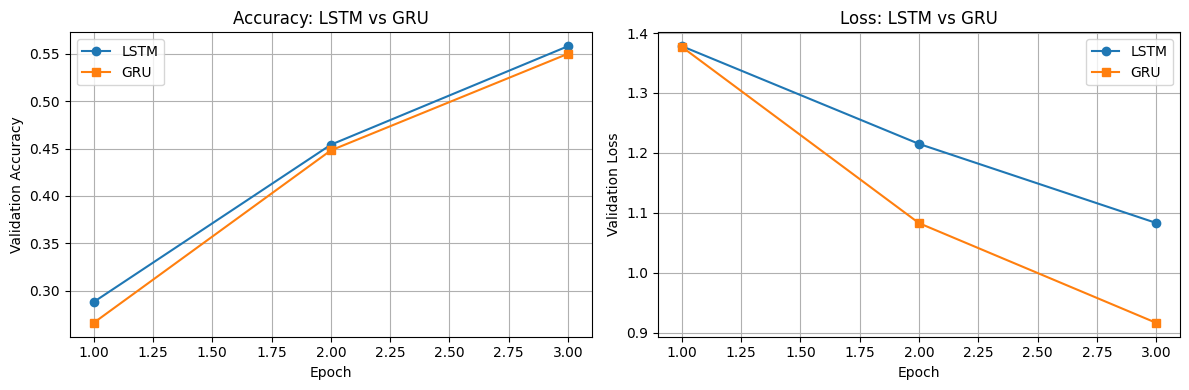


Stress test: krótkie (max_len=20) vs długie (max_len=80) sekwencje

LSTM max_len=20
  Epoch 1: train_loss=1.1423 val_loss=0.7573 val_acc=0.6800 time=0.5s
  Epoch 2: train_loss=0.6348 val_loss=0.5711 val_acc=0.8000 time=0.3s
  Epoch 3: train_loss=0.4882 val_loss=0.5233 val_acc=0.8240 time=0.3s

GRU max_len=20
  Epoch 1: train_loss=1.2237 val_loss=0.8484 val_acc=0.6300 time=0.3s
  Epoch 2: train_loss=0.6018 val_loss=0.5556 val_acc=0.7940 time=0.3s
  Epoch 3: train_loss=0.4561 val_loss=0.5319 val_acc=0.8060 time=0.3s

LSTM max_len=80
  Epoch 1: train_loss=1.3882 val_loss=1.3867 val_acc=0.2380 time=1.3s
  Epoch 2: train_loss=1.3858 val_loss=1.3882 val_acc=0.2420 time=1.2s
  Epoch 3: train_loss=1.3865 val_loss=1.3872 val_acc=0.2460 time=1.2s

GRU max_len=80
  Epoch 1: train_loss=1.3871 val_loss=1.3872 val_acc=0.2420 time=0.9s
  Epoch 2: train_loss=1.3868 val_loss=1.3879 val_acc=0.2420 time=0.9s
  Epoch 3: train_loss=1.3858 val_loss=1.3871 val_acc=0.2460 time=0.9s

=== Tabela stress test ==

In [5]:
# === RecurrentClassifier (LSTM / GRU) ===
class RecurrentClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 model_type="lstm", num_layers=1, bidirectional=False,
                 dropout=0.2, padding_idx=0, pretrained_matrix=None, freeze_embeddings=False):
        super().__init__()
        self.model_type = model_type.lower()
        self.hidden_dim = hidden_dim
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        if pretrained_matrix is not None:
            self.embedding.weight.data.copy_(pretrained_matrix)
        self.embedding.weight.requires_grad = not freeze_embeddings

        recurrent_dropout = dropout if num_layers > 1 else 0.0

        if self.model_type == "lstm":
            self.recurrent = nn.LSTM(
                input_size=embedding_dim, hidden_size=hidden_dim,
                num_layers=num_layers, batch_first=True,
                dropout=recurrent_dropout, bidirectional=bidirectional,
            )
        elif self.model_type == "gru":
            self.recurrent = nn.GRU(
                input_size=embedding_dim, hidden_size=hidden_dim,
                num_layers=num_layers, batch_first=True,
                dropout=recurrent_dropout, bidirectional=bidirectional,
            )
        else:
            raise ValueError("model_type must be 'lstm' or 'gru'")

        direction_factor = 2 if bidirectional else 1
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * direction_factor, num_classes),
        )

    def forward(self, x):
        embedded = self.embedding(x)
        if self.model_type == "lstm":
            output, (h_n, c_n) = self.recurrent(embedded)
        else:
            output, h_n = self.recurrent(embedded)
        logits = self.classifier(output[:, -1, :])
        return logits

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_and_evaluate(model, train_loader, val_loader, epochs=3, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "epoch_time": []}

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        correct, total, vloss = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                vloss += criterion(out, yb).item()
                correct += (out.argmax(1) == yb).sum().item()
                total += yb.size(0)

        epoch_time = time.time() - t0
        tl = total_loss / len(train_loader)
        vl = vloss / len(val_loader)
        va = correct / total
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        history["epoch_time"].append(epoch_time)
        print(f"  Epoch {epoch+1}: train_loss={tl:.4f} val_loss={vl:.4f} val_acc={va:.4f} time={epoch_time:.1f}s")

    return history

# === Hyperparametery ===
emb_dim = 50
hid_dim = 128
n_classes = 4
n_epochs = 3
batch_size = 64
lr = 1e-3

train_loader_4 = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader_4 = DataLoader(val_dataset, batch_size=batch_size)

# === LSTM ===
print("=== LSTM ===")
torch.manual_seed(SEED)
lstm_model = RecurrentClassifier(
    len(vocab_list), emb_dim, hid_dim, n_classes,
    model_type="lstm", padding_idx=pad_idx, pretrained_matrix=embedding_matrix
).to(device)
print(f"Trainable parameters: {count_params(lstm_model)}")
lstm_hist = train_and_evaluate(lstm_model, train_loader_4, val_loader_4, epochs=n_epochs, lr=lr)

# === GRU ===
print("\n=== GRU ===")
torch.manual_seed(SEED)
gru_model = RecurrentClassifier(
    len(vocab_list), emb_dim, hid_dim, n_classes,
    model_type="gru", padding_idx=pad_idx, pretrained_matrix=embedding_matrix
).to(device)
print(f"Trainable parameters: {count_params(gru_model)}")
gru_hist = train_and_evaluate(gru_model, train_loader_4, val_loader_4, epochs=n_epochs, lr=lr)

# === Tabela porównawcza ===
print("\n=== Tabela porównawcza ===\n")
comp_df = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "Parametry": [count_params(lstm_model), count_params(gru_model)],
    "Final train loss": [f"{lstm_hist['train_loss'][-1]:.4f}", f"{gru_hist['train_loss'][-1]:.4f}"],
    "Final val loss": [f"{lstm_hist['val_loss'][-1]:.4f}", f"{gru_hist['val_loss'][-1]:.4f}"],
    "Final val acc": [f"{lstm_hist['val_acc'][-1]:.4f}", f"{gru_hist['val_acc'][-1]:.4f}"],
    "Czas treningu [s]": [f"{sum(lstm_hist['epoch_time']):.1f}", f"{sum(gru_hist['epoch_time']):.1f}"],
})
print(comp_df.to_markdown(index=False))

# === Plot ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, n_epochs + 1)

axes[0].plot(epochs_range, lstm_hist["val_acc"], "o-", label="LSTM")
axes[0].plot(epochs_range, gru_hist["val_acc"], "s-", label="GRU")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title("Accuracy: LSTM vs GRU")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, lstm_hist["val_loss"], "o-", label="LSTM")
axes[1].plot(epochs_range, gru_hist["val_loss"], "s-", label="GRU")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].set_title("Loss: LSTM vs GRU")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# === Option A: Stress test — krótkie vs długie sekwencje ===
print("\n" + "="*60)
print("Stress test: krótkie (max_len=20) vs długie (max_len=80) sekwencje")
print("="*60)

stress_results = []
for test_max_len in [20, 80]:
    X_tr_stress = torch.tensor([encode(t, ml=test_max_len) for t in train_texts], dtype=torch.long)
    X_vl_stress = torch.tensor([encode(t, ml=test_max_len) for t in val_texts], dtype=torch.long)
    tr_ds = torch.utils.data.TensorDataset(X_tr_stress, y_train)
    vl_ds = torch.utils.data.TensorDataset(X_vl_stress, y_val)
    tr_dl = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)
    vl_dl = DataLoader(vl_ds, batch_size=batch_size)

    for mtype in ["lstm", "gru"]:
        torch.manual_seed(SEED)
        m = RecurrentClassifier(
            len(vocab_list), emb_dim, hid_dim, n_classes,
            model_type=mtype, padding_idx=pad_idx, pretrained_matrix=embedding_matrix
        ).to(device)
        print(f"\n{mtype.upper()} max_len={test_max_len}")
        hist = train_and_evaluate(m, tr_dl, vl_dl, epochs=n_epochs, lr=lr)
        stress_results.append({
            "Model": mtype.upper(),
            "max_len": test_max_len,
            "Val acc": f"{hist['val_acc'][-1]:.4f}",
            "Val loss": f"{hist['val_loss'][-1]:.4f}",
            "Czas [s]": f"{sum(hist['epoch_time']):.1f}",
        })

print("\n=== Tabela stress test ===\n")
stress_df = pd.DataFrame(stress_results)
print(stress_df.to_markdown(index=False))

## Dyskusja — Task 4

### 1. Który model osiągnął lepszą validation accuracy?
W głównym eksperymencie (max_len=50, 3 epoki) **LSTM osiągnął 55.8%**, a **GRU 55.0%** — wyniki bardzo zbliżone, z minimalną przewagą LSTM. Na tak małym zbiorze (2000 przykładów) różnica ~0.8 p.p. nie jest statystycznie istotna i mogłaby się odwrócić przy innym seedzie. Oba modele radzą sobie porównywalnie z klasyfikacją 4-klasową AG_NEWS.

### 2. Który model miał mniej parametrów?
**GRU miał 397,036 parametrów, LSTM — 420,076.** GRU ma ~5.5% mniej parametrów. Wynika to z architektury:
- LSTM ma **4 zestawy wag** (input, forget, output gate + cell candidate): $4 \times (d \cdot h + h \cdot h + h) = 4h(d+h+1)$
- GRU ma **3 zestawy wag** (reset, update gate + candidate): $3 \times (d \cdot h + h \cdot h + h) = 3h(d+h+1)$

Dla $d=50$, $h=128$: różnica w parametrach rekurencyjnych to dokładnie 25% (3/4 vs 4/4). Reszta parametrów (embedding, klasyfikator) jest taka sama.

### 3. Który model trenował się szybciej?
**GRU trenował się szybciej** — 1.8s łącznie vs 2.1s dla LSTM (~14% szybciej). Wynika to z mniejszej liczby operacji macierzowych (3 bramki vs 4).

### 4. Czy wynik potwierdza teorię, że GRU ma mniej parametrów niż LSTM?
**Tak** — GRU ma 397k vs LSTM 420k parametrów, co zgadza się z teoretycznym stosunkiem 3:4 dla warstwy rekurencyjnej.

### Analiza stress testu (krótkie vs długie sekwencje)

Wyniki stress testu są **zaskakujące i pouczające**:

| Model | max_len=20 | max_len=50 (główny) | max_len=80 |
|-------|-----------|---------------------|-----------|
| LSTM  | **82.4%** | 55.8%               | 24.6%     |
| GRU   | **80.6%** | 55.0%               | 24.6%     |

**Krótsze sekwencje dają znacznie lepsze wyniki**, co jest odwrotne do naiwnej intuicji. Powody:

1. **Problem paddingu** — nasz klasyfikator używa `output[:, -1, :]`, czyli wyjście z **ostatniego kroku czasowego**. Przy max_len=80 większość tekstu (typowa długość ~20-40 słów) jest uzupełniona zerami. Model przetwarza dziesiątki tokenów `<pad>`, które stopniowo "wymywają" użyteczną informację z hidden state.

2. **Krótkie sekwencje (max_len=20)** — ostatni krok czasowy jest blisko rzeczywistego tekstu, więc hidden state zachowuje silny sygnał semantyczny. Stąd accuracy ~82%.

3. **Długie sekwencje (max_len=80)** — accuracy ~25% to poziom losowy (4 klasy). Hidden state po 40-60 krokach paddingu praktycznie "zapomniał" o treści tekstu.

**Wnioski:** Aby naprawić ten problem, należałoby:
- Użyć `pack_padded_sequence` / `pad_packed_sequence` (ignoruje padding)
- Lub wybrać hidden state z ostatniego **niepaddowanego** tokena zamiast ostatniego w sekwencji
- Lub użyć average pooling po wszystkich nie-paddowanych krokach

Zarówno LSTM, jak i GRU cierpią na ten sam problem — oba spadają do ~25% przy max_len=80. Mechanizm bramkowania (forget/update gate) teoretycznie powinien pozwalać „ignorować" nieistotne wejścia, ale w praktyce dziesiątki identycznych tokenów `<pad>` skutecznie zamazują wcześniejszy sygnał.

---

# Final Questions

### 1. Jaka jest różnica między wektorami one-hot a gęstymi word embeddingami?
**One-hot** to wektor o wymiarze $V$ (rozmiar słownika), gdzie dokładnie jeden element = 1, reszta = 0. Jest rzadki, wysoko-wymiarowy i nie koduje żadnych relacji semantycznych — każde dwa słowa są jednakowo „dalekie" od siebie (odległość = $\sqrt{2}$).

**Gęsty word embedding** to wektor o niskim wymiarze (np. 50-300), gdzie każdy element jest liczbą rzeczywistą. Embeddingi są uczone tak, by słowa o podobnym znaczeniu miały bliskie wektory. Są efektywne obliczeniowo i kodują relacje semantyczne.

### 2. Co Word2Vec próbuje przewidzieć?
W wariancie **Skip-gram**: mając słowo centralne (center word), model przewiduje słowa kontekstowe (outside words) w oknie o ustalonej szerokości.

W wariancie **CBOW** (Continuous Bag of Words): mając słowa kontekstowe, model przewiduje słowo centralne.

W obu przypadkach model uczy się wektorów embeddingów, które maksymalizują prawdopodobieństwo zaobserwowanych par (center, context) w korpusie.

### 3. Dlaczego pełny softmax jest kosztowny dla dużych słowników?
Obliczenie prawdopodobieństwa softmax wymaga:
$$P(o|c) = \frac{\exp(u_o^T v_c)}{\sum_{k=1}^{V} \exp(u_k^T v_c)}$$

Mianownik sumuje po **wszystkich $V$ słowach** w słowniku. Dla $V = 500\,000$ oznacza to 500 tys. iloczynów skalarnych + eksponent + sumę — **dla każdej pary treningowej**. Przy milionach par treningowych czyni to trening niewykonalnym. Dlatego stosuje się przybliżenia: negative sampling ($O(K)$ zamiast $O(V)$) lub hierarchical softmax ($O(\log V)$).

### 4. Czym jest hidden state w RNN?
Hidden state $h_t \in \mathbb{R}^{h}$ to wektor reprezentujący **skumulowaną informację** o dotychczas przetworzonych elementach sekwencji. W każdym kroku czasowym jest aktualizowany:
$$h_t = f(x_t, h_{t-1})$$
gdzie $f$ to funkcja rekurencyjna (np. $\tanh$ w vanilla RNN, bramkowana w LSTM/GRU).

Hidden state pełni rolę „pamięci roboczej" sieci — pozwala podejmować decyzje na podstawie kontekstu, a nie tylko bieżącego tokenu.

### 5. Dlaczego LSTM i GRU zazwyczaj działają lepiej niż vanilla RNN na dłuższych sekwencjach?
Vanilla RNN cierpi na **problem zanikającego gradientu** — przy propagacji wstecz przez wiele kroków, gradient jest wielokrotnie mnożony przez tę samą macierz $W_{hh}$, co powoduje jego wykładniczy zanik.

LSTM rozwiązuje to przez **cell state** $c_t$ — osobny kanał informacji, który przepływa przez sekwencję z multiplikatywnymi bramkami (forget gate, input gate). Gradient może przepływać przez cell state niemal bez zmian, co umożliwia uczenie się zależności na setki kroków.

GRU osiąga podobny efekt prostszą architekturą — bramka update gate kontroluje, ile informacji z przeszłości zachować, a ile zastąpić nową.

### 6. Jaka jest główna różnica architektoniczna między LSTM a GRU?
**LSTM** ma:
- **cell state** $c_t$ — osobny wektor pamięci długoterminowej
- **3 bramki**: forget ($f_t$), input ($i_t$), output ($o_t$)
- **candidate cell** $\tilde{c}_t$
- Łącznie 4 zestawy parametrów

**GRU** ma:
- **brak osobnego cell state** — cała informacja jest w hidden state $h_t$
- **2 bramki**: reset ($r_t$), update ($z_t$)
- **candidate hidden** $\tilde{h}_t$
- Łącznie 3 zestawy parametrów

Kluczowa różnica: LSTM rozdziela pamięć krótkoterminową (hidden state) od długoterminowej (cell state), podczas gdy GRU łączy je w jednym wektorze. GRU jest prostszy (~25% mniej parametrów) i często osiąga porównywalnie dobre wyniki, ale LSTM ma większą pojemność ekspresyjną dzięki dodatkowej bramce i cell state.